In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
import seaborn as sns

q-learning

In [7]:
EPISODES = 250000
GAMMA = 1.0
ALPHA = 0.1
EPSILON = 0.1

env = gym.make("Blackjack-v1", sab=False)

eps_greedy = lambda q_vals, eps: np.random.randint(len(q_vals)) if np.random.rand() < eps else np.argmax(q_vals)
def state_to_idx(s): return s[0]-1, s[1]-1, s[2]


#init q(s,a) = 0, q(terminal) = 0
q = np.zeros((21, 10, 2, 2)) #21x10x2x2 action-states
# q = np.random.uniform(-1, 1, size=(21, 10, 2, 2)) #21x10x2x2 action-states

#for episode in episodes
wins = []
for episode in range(EPISODES):
    #init s
    s, _ = env.reset()
    #pick a as eps-greedy
    s1, s2, s3 = state_to_idx(s)
    
    while True:
        #pick a as eps-greedy
        a = eps_greedy(q[s1, s2, s3], EPSILON)

        #get s', r from a
        s_n, r, term, trunc, info = env.step(a)

        if term or trunc:
            q[s1, s2, s3, a] += ALPHA * (r - q[s1, s2, s3, a])
            wins.append(r > 0)
            break
        
        s1_n, s2_n, s3_n = state_to_idx(s_n)
        #update q
        q[s1, s2, s3, a] += ALPHA * (r + GAMMA * np.max(q[s1_n, s2_n, s3_n]) - q[s1, s2, s3, a])

        #update s, a
        s1, s2, s3 = s1_n, s2_n, s3_n



env.close()


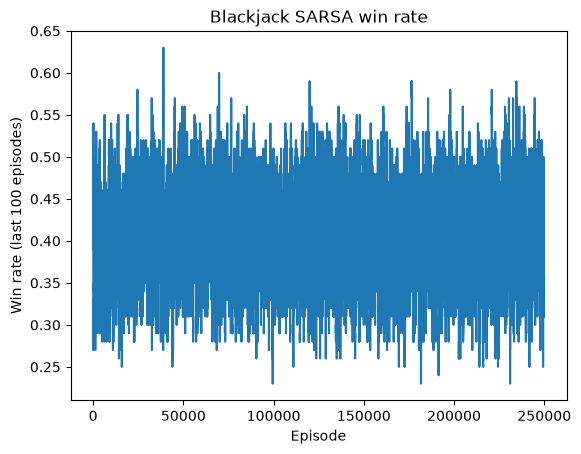

In [8]:
window = 100
win_rate = np.convolve(wins, np.ones(window) / window, mode='valid')

plt.plot(win_rate)
plt.xlabel('Episode')
plt.ylabel(f'Win rate (last {window} episodes)')
plt.title('Blackjack SARSA win rate')
plt.show()

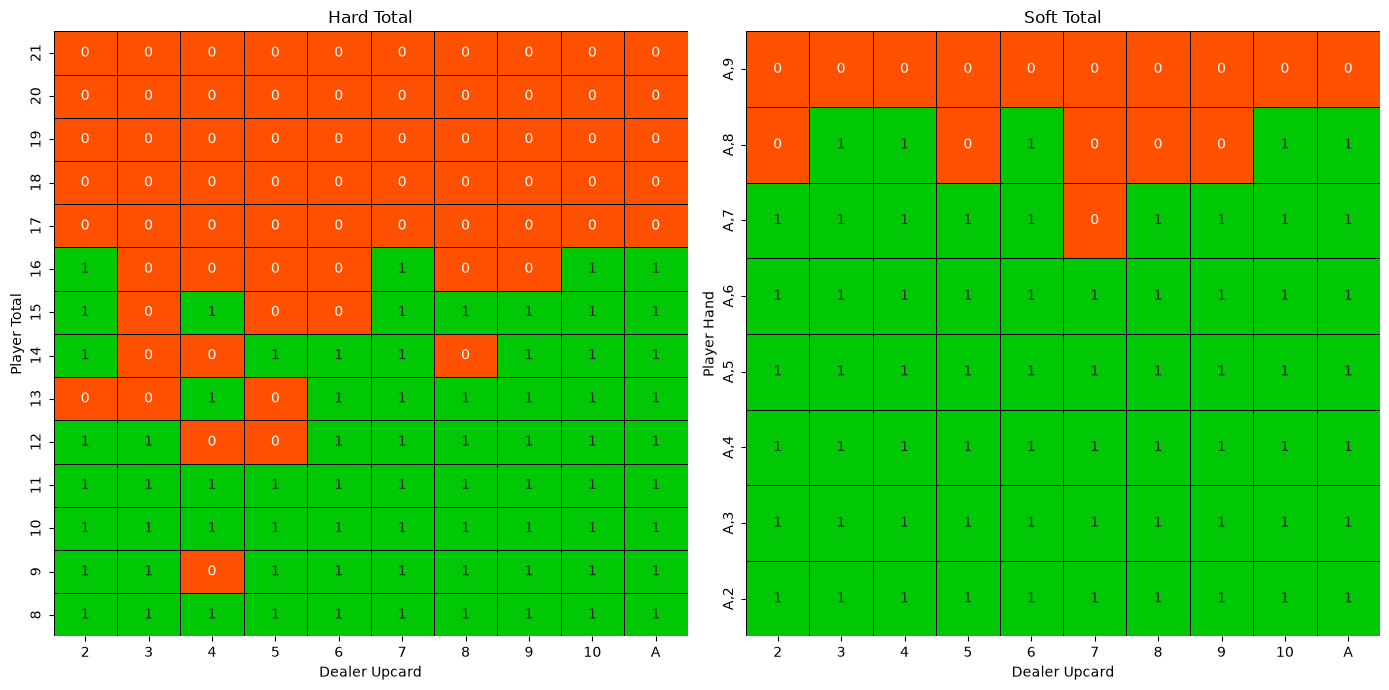

In [9]:

pink = '#FF5000' 
green = '#00C805' 
action_cmap = ListedColormap([pink, green])

dealer_upcards = [(i, str(i)) for i in range(2, 11)] + [(1, 'A')]

hard_table = []
soft_table = []
for player_sum in range(8, 22):
    pi = player_sum - 1
    for dealer_up, dealer_label in dealer_upcards:
        di = dealer_up - 1
        hard_table.append({
            'Player': player_sum,
            'Dealer': dealer_label,
            'Action': np.argmax(q[pi, di, 0]),
        })

for player_sum in range(13, 21):
    pi = player_sum - 1
    hand = f"A,{player_sum - 11}"
    for dealer_up, dealer_label in dealer_upcards:
        di = dealer_up - 1
        soft_table.append({
            'Player': hand,
            'Dealer': dealer_label,
            'Action': np.argmax(q[pi, di, 1]),
        })

col_order = [str(i) for i in range(2, 11)] + ['A']
soft_hand_order = [f"A,{i}" for i in range(9, 1, -1)]
hard_pivot = pd.DataFrame(hard_table).pivot(index='Player', columns='Dealer', values='Action')[col_order].sort_index(ascending=False)
soft_pivot = pd.DataFrame(soft_table).pivot(index='Player', columns='Dealer', values='Action')[col_order].reindex(soft_hand_order)

plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
sns.heatmap(hard_pivot, cmap=action_cmap, cbar=False,
            linewidths=.5, linecolor='black', annot=True, fmt='d')
plt.title('Hard Total')
plt.xlabel('Dealer Upcard')
plt.ylabel('Player Total')

plt.subplot(1, 2, 2)
sns.heatmap(soft_pivot, cmap=action_cmap, cbar=False,
            linewidths=.5, linecolor='black', annot=True, fmt='d')
plt.title('Soft Total')
plt.xlabel('Dealer Upcard')
plt.ylabel('Player Hand')

plt.tight_layout()
plt.show()